In [140]:
from pm4py.objects.bpmn.obj import BPMN
from pm4py.objects.log.obj import EventLog
from pm4py.objects.ocel.obj import OCEL
from pm4py.objects.petri_net.obj import PetriNet, Marking
from pm4py.objects.process_tree.obj import ProcessTree
from pm4py.objects.log.importer.xes import importer as xes_importer
import pandas as pd
import pm4py


In [141]:
# read xes file and convert it into a dataframe
log: pd.DataFrame = pm4py.read_xes("../data/raw/BPI_Challenge_2012.xes.gz")

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

In [142]:
log.head(50)

,org:resource,lifecycle:transition,concept:name,time:timestamp,case:REG_DATE,case:concept:name,case:AMOUNT_REQ
0,112,COMPLETE,A_SUBMITTED,2011-10-01 00:38:44.546000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
1,112,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
2,112,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
3,112,SCHEDULE,W_Completeren aanvraag,2011-10-01 00:39:38.875000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
5,10862,COMPLETE,A_ACCEPTED,2011-10-01 11:42:43.308000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
6,10862,COMPLETE,O_SELECTED,2011-10-01 11:45:09.243000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
7,10862,COMPLETE,A_FINALIZED,2011-10-01 11:45:09.243000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
8,10862,COMPLETE,O_CREATED,2011-10-01 11:45:11.197000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
9,10862,COMPLETE,O_SENT,2011-10-01 11:45:11.380000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000


In [143]:
log[log["case:concept:name"] == "173688"]

,org:resource,lifecycle:transition,concept:name,time:timestamp,case:REG_DATE,case:concept:name,case:AMOUNT_REQ
0,112,COMPLETE,A_SUBMITTED,2011-10-01 00:38:44.546000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
1,112,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
2,112,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
3,112,SCHEDULE,W_Completeren aanvraag,2011-10-01 00:39:38.875000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
5,10862,COMPLETE,A_ACCEPTED,2011-10-01 11:42:43.308000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
6,10862,COMPLETE,O_SELECTED,2011-10-01 11:45:09.243000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
7,10862,COMPLETE,A_FINALIZED,2011-10-01 11:45:09.243000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
8,10862,COMPLETE,O_CREATED,2011-10-01 11:45:11.197000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
9,10862,COMPLETE,O_SENT,2011-10-01 11:45:11.380000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000


In [144]:
# for the case id (173688) the work item (W_Nabellen offertes/W_Calling after sent offers) was used multiple time. 
# meaning they tried to reach the customer multiple times over 9 days 2011-10-01 12:15:41.290000+00:00 - 2011-10-10 11:33:05.791000+00:00

In [145]:
# checking multiple rewords across the whole dataset
starts = log[log["lifecycle:transition"] == "START"]
rework = starts.groupby(["case:concept:name", "concept:name"]).size()
rework[rework > 1].describe()

count    13029.000000
mean         4.782792
std          4.090841
min          2.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         60.000000
dtype: float64

In [146]:
# rework: (case, work item) pairs where the same work item was started more than once
rework[rework > 1].value_counts().sort_index()
rework[rework > 1].index.get_level_values(0).nunique()
rework[rework > 1].groupby(level=1).size().sort_values(ascending=False)

concept:name
W_Completeren aanvraag            4413
W_Nabellen offertes               4269
W_Valideren aanvraag              2020
W_Nabellen incomplete dossiers    1474
W_Afhandelen leads                 772
W_Beoordelen fraude                 81
dtype: int64

In [147]:
# checking the sum of nun resources 
log["org:resource"].isnull().sum()

np.int64(18010)

In [148]:
# 18010 null resources / 262200 (6.8%)

In [149]:
# in which life cycles?
log[log["org:resource"].isna()]["lifecycle:transition"].value_counts()

lifecycle:transition
COMPLETE    8142
START       8000
SCHEDULE    1868
Name: count, dtype: int64

In [150]:
# in which activity
log[log["org:resource"].isna()]["concept:name"].value_counts()

concept:name
W_Nabellen offertes               7314
W_Completeren aanvraag            6478
W_Nabellen incomplete dossiers    1960
W_Afhandelen leads                1634
W_Valideren aanvraag               619
W_Beoordelen fraude                  4
W_Wijzigen contractgegevens          1
Name: count, dtype: int64

In [151]:
# from documentation: 
# https://ais.win.tue.nl/bpi/2012/challenge.html
# States starting with ‘A_’ -> States of the application
# States starting with ‘O_’ -> States of the offer belonging to the application
# States starting with ‘W_’ -> States of the work item belonging to the application
# COMPLETE The task (of type ‘A_’ or ‘O_’) is completed
# SCHEDULE The work item (of type ‘W_’) is created in the queue (automatic step following manual actions)
# START The work item (of type ‘W_’) is obtained by the resource
# COMPLETE The work item (of type ‘W_’) is released by the resource and put back in the queue or transferred to another queue (SCHEDULE)

In [152]:
# cross tabing activities against lifecycle transitions
# double-checking as according to the documentation, only work items should have all three transitions
prefix = log["concept:name"].str.strip("_").str[0]
pd.crosstab(prefix, log["lifecycle:transition"])

lifecycle:transition,COMPLETE,SCHEDULE,START
concept:name,,,
A,60849,0,0
O,31244,0,0
W,72413,26318,71376


In [153]:
# checking events with the same exact timestamp (concurrent events)  
timestamp_ties = log.groupby(["case:concept:name", "time:timestamp"]).size()

In [154]:
timestamp_ties[timestamp_ties > 1].sum()

np.int64(25369)

In [155]:
# 25369/262200 events share the same timestamp within the same case (around 9.7%)

In [156]:
# concept:name 
log["concept:name"].unique()

array(['A_SUBMITTED', 'A_PARTLYSUBMITTED', 'A_PREACCEPTED',
       'W_Completeren aanvraag', 'A_ACCEPTED', 'O_SELECTED',
       'A_FINALIZED', 'O_CREATED', 'O_SENT', 'W_Nabellen offertes',
       'O_SENT_BACK', 'W_Valideren aanvraag', 'A_REGISTERED',
       'A_APPROVED', 'O_ACCEPTED', 'A_ACTIVATED', 'O_CANCELLED',
       'W_Wijzigen contractgegevens', 'A_DECLINED', 'A_CANCELLED',
       'W_Afhandelen leads', 'O_DECLINED',
       'W_Nabellen incomplete dossiers', 'W_Beoordelen fraude'],
      dtype=object)

In [157]:
# first activity per case 
fa = log.groupby("case:concept:name")["concept:name"].first()
fa

case:concept:name
173688    A_SUBMITTED
173691    A_SUBMITTED
173694    A_SUBMITTED
173697    A_SUBMITTED
173700    A_SUBMITTED
             ...     
214364    A_SUBMITTED
214367    A_SUBMITTED
214370    A_SUBMITTED
214373    A_SUBMITTED
214376    A_SUBMITTED
Name: concept:name, Length: 13087, dtype: object

In [158]:
fa.value_counts()

concept:name
A_SUBMITTED    13087
Name: count, dtype: int64

In [159]:
# lifecycle:transition
log["org:resource"].nunique()

68

In [160]:
log["case:concept:name"].nunique()

13087

In [161]:
# calculating the percentage of approved and declined cases over the total
total = log["case:concept:name"].nunique()
approved = (log["concept:name"] == "A_APPROVED").sum()
declined = (log["concept:name"] == "A_DECLINED").sum()
print("total:", total)
print("approved:", approved)
print("declined:", declined)

total: 13087
approved: 2246
declined: 7635


In [162]:
approved_percentage = (approved/total) * 100
approved_percentage

np.float64(17.162069229005883)

In [163]:
declined_percentage = (declined/total) * 100
declined_percentage

np.float64(58.340337739741734)

In [164]:
# checking which cases do not have an outcome (in progress /cut off data)
outcomes = ["A_APPROVED", "A_DECLINED", "A_CANCELLED"]

labels = (
    log[log["concept:name"].isin(outcomes)]
    .groupby("case:concept:name")["concept:name"]
    .agg(list)
)

labels.apply(len).value_counts()

concept:name
1    12688
Name: count, dtype: int64

In [165]:
# 12688/13087 cases have an actual outcome (around 97%)
# the remaining cases might still be in progress 

In [166]:
# filtering the log from cases without outcomes
log_complete = log[log["case:concept:name"].isin(labels.index)]

In [167]:
# case duration: first event -> last event, split by outcome
duration = log_complete.groupby("case:concept:name")["time:timestamp"].agg(["min", "max"])
duration

,min,max
case:concept:name,,
173688,2011-10-01 00:38:44.546000+00:00,2011-10-13 10:37:37.026000+00:00
173691,2011-10-01 08:08:58.256000+00:00,2011-10-10 14:17:34.633000+00:00
173694,2011-10-01 08:10:30.287000+00:00,2012-02-15 12:29:26.299000+00:00
173697,2011-10-01 08:11:08.866000+00:00,2011-10-01 08:11:46.420000+00:00
173700,2011-10-01 08:15:39.894000+00:00,2011-10-01 08:16:21.037000+00:00
...,...,...
214349,2012-02-29 22:33:12.182000+00:00,2012-03-01 09:25:37.085000+00:00
214361,2012-02-29 23:11:37.975000+00:00,2012-03-13 11:21:45.661000+00:00
214367,2012-02-29 23:28:41.098000+00:00,2012-02-29 23:29:21.958000+00:00


In [168]:
duration["days"] = (duration["max"] - duration["min"]).dt.total_seconds() / 86400
duration

,min,max,days
case:concept:name,,,
173688,2011-10-01 00:38:44.546000+00:00,2011-10-13 10:37:37.026000+00:00,12.415885
173691,2011-10-01 08:08:58.256000+00:00,2011-10-10 14:17:34.633000+00:00,9.255977
173694,2011-10-01 08:10:30.287000+00:00,2012-02-15 12:29:26.299000+00:00,137.179815
173697,2011-10-01 08:11:08.866000+00:00,2011-10-01 08:11:46.420000+00:00,0.000435
173700,2011-10-01 08:15:39.894000+00:00,2011-10-01 08:16:21.037000+00:00,0.000476
...,...,...,...
214349,2012-02-29 22:33:12.182000+00:00,2012-03-01 09:25:37.085000+00:00,0.453066
214361,2012-02-29 23:11:37.975000+00:00,2012-03-13 11:21:45.661000+00:00,12.507033
214367,2012-02-29 23:28:41.098000+00:00,2012-02-29 23:29:21.958000+00:00,0.000473


In [169]:
# case duration: first event -> last event, split by outcome
duration["outcome"] = labels.apply(lambda x: x[0])
duration.groupby("outcome")["days"].describe()

,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
A_APPROVED,2246.0,16.730068,9.776095,0.008199,10.637065,14.485519,19.978490,137.179815
A_CANCELLED,2807.0,18.595300,14.559772,0.000771,6.747935,16.846095,30.764165,91.413613
A_DECLINED,7635.0,2.047581,5.993729,0.000021,0.000447,0.007829,0.491189,76.946342


In [170]:
# request amount is currently a string value
log["case:AMOUNT_REQ"] = log["case:AMOUNT_REQ"].astype(int)

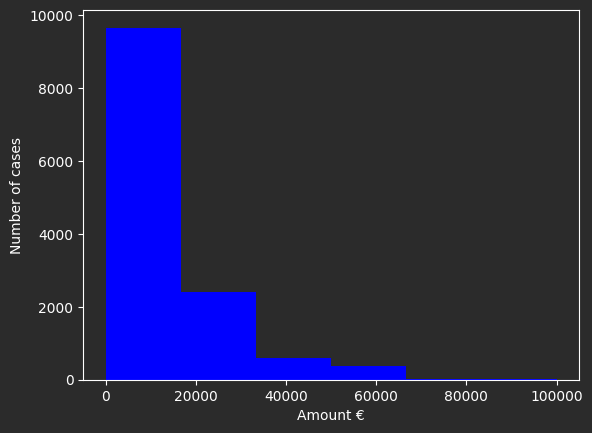

In [171]:
# displaying requested amount
import matplotlib.pyplot as plt

amt = log.groupby("case:concept:name")["case:AMOUNT_REQ"].first()

plt.hist(amt, bins=6, color='blue')
plt.xlabel("Amount €")
plt.ylabel("Number of cases")
plt.savefig("../reports/figures/requested_amount.png", bbox_inches="tight")
plt.show()

In [139]:
amt.describe()

count    13087.000000
mean     13573.356079
std      12226.692089
min          0.000000
25%       5000.000000
50%      10000.000000
75%      17620.000000
max      99999.000000
Name: case:AMOUNT_REQ, dtype: float64

In [127]:
# investigating the zero request amounts
outcome = labels.apply(lambda x: x[0])
(amt == 0).sum()
outcome[amt[amt == 0].index].value_counts()

concept:name
A_CANCELLED    1
Name: count, dtype: int64

In [128]:
# and the highest value
(amt == 99999).sum()
outcome[amt[amt == 99999].index].value_counts()

concept:name
A_DECLINED     1
A_CANCELLED    1
Name: count, dtype: int64

In [129]:
# second highest after 0
amt[amt > 0].min()

np.int64(1)

In [131]:
amt.sort_values().head(20)

case:concept:name
193378      0
193318      1
193267     10
188398     12
193393     13
189925     25
178671     50
185186     50
209185     70
184862     98
189727    100
188625    100
188651    100
175132    100
208841    100
207963    100
210713    100
186142    150
211618    150
200344    150
Name: case:AMOUNT_REQ, dtype: int64

In [172]:
'''
Findings of the analysis:

1. Work items are frequently started more than once within the same case (rework). 
Most affected are filling in application information (W_Completerena anvraag) 4413 case work items,
calling a customer after an offer was sent (W_Nabellen offertes) 4269 cases, 
validating the application (W_Valideren aanvraag) 2020 cases and calling a customer for missing information
(W_Nabellen incomplete dossiers) 1474 cases.

2. 18010 out of 262200 events (around 6.9%) have no org:resource. All of them are W_ (work items) events.
--> Therefore, missing resource is structural and not at random. It marks work items with no user recorded.

3. 25369 out of 262200 events (9.7%) share a timestamp with another event in the same case, across 11374 tied groups.

4. The log contains 24 distinct activities.

5. The log contains 3 lifecycle transitions (schedule, start and complete).

6. Every case starts with A_SUBMITTED (13087 out of 13087 cases).

7. Outcomes: 58.3% declined (7625 cases), 21.4% cancelled (2807 cases) 
and 17.2% approved (2246 cases), 3.1% with no outcomes i.e. cut off data (399 cases).

8. The cases without an outcome are right truncated / still in progress when the log was extracted, 
and were excluded from the duration statistics.

9. Median & (mean) case duration: 
approved  14.4 & (16.7) days, 
cancelled 16.8 & (18.5) days and 
declined 0.007 & (2.04) days.

10. Median & (mean) requested amount: 
10000 & (13573.3) €
highest amount is €99,999 (two cases: one declined, one cancelled) and 
lowest amount is €0 (one case, cancelled) "a junk submission".

'''

'\nFindings of the analysis:\n\n1. Work items are frequently started more than once within the same case (rework). \nMost affected are filling in application information (W_Completerena anvraag) 4413 case work items,\ncalling a customer after an offer was sent (W_Nabellen offertes) 4269 cases, \nvalidating the application (W_Valideren aanvraag) 2020 cases and calling a customer for missing information\n(W_Nabellen incomplete dossiers) 1474 cases.\n\n2. 18010 out of 262200 events (around 6.9%) have no org:resource. All of them are W_ (work items) events.\n--> Therefore, missing resource is structural and not at random. It marks work items with no user recorded.\n\n3. 25369 out of 262200 events (9.7%) share a timestamp with another event in the same case, across 11374 tied groups.\n\n4. The log contains 24 distinct activities.\n\n5. The log contains 3 lifecycle transitions (schedule, start and complete).\n\n6. Every case starts with A_SUBMITTED (13087 out of 13087 cases).\n\n7. Outcomes: